<a href="https://colab.research.google.com/github/chamarairesh1982/LearnPython/blob/main/COMP70049_Improved_Data_Preprocessing_Workbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP70049 – Improved Data Preprocessing and EDA Workbook

**Module:** Machine Learning in Cyber  
**Purpose:** An improved, Google Colab-compatible version of the Week 2 lecturer example.

## Learning outcomes

By completing this notebook, you will be able to:

1. Profile a dataset and identify quality problems.
2. Perform univariate and bivariate exploratory data analysis (EDA).
3. Handle duplicates, inconsistent categories, missing values and invalid values.
4. Detect potential outliers using the interquartile range (IQR).
5. Encode and scale features without leaking test information into training.
6. Build a reusable preprocessing and classification pipeline.

> **Important:** This deliberately tiny student dataset is for learning preprocessing. Its model scores are not scientifically meaningful and must not be presented as reliable evidence.

## 1. Setup

A CPU runtime is sufficient. This practical does not need a GPU or TPU.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("Setup complete")

Setup complete


## 2. Create the lecturer's dummy dataset

The dataset intentionally contains problems:

- Missing values
- One duplicated record
- Inconsistent spelling (`Colombo` and `colombo`)
- Impossible values such as age 120, attendance 150 and exam mark 110
- An imbalanced target (`Placement`)

In [2]:
data = {
    "Student_ID": [101, 102, 103, 104, 105, 106, 107, 106],
    "Age": [20, 21, np.nan, 22, 55, 19, 120, 19],
    "Gender": ["F", "M", "M", "F", "F", "M", "F", "M"],
    "Department": ["IT", "CS", "IT", "SE", "CS", "IT", "SE", "IT"],
    "Attendance": [90, 85, 80, np.nan, 75, 88, 150, 88],
    "Assignment": [78, 67, np.nan, 88, 55, 81, 90, 81],
    "Exam": [80, 70, 75, 90, 60, 82, 110, 82],
    "City": ["Colombo", "Kandy", "colombo", "Galle", "Kandy", "Colombo", "Matara", "Colombo"],
    "Placement": ["Yes", "No", "Yes", "Yes", "No", "Yes", "Yes", "Yes"],
}

raw_df = pd.DataFrame(data)
raw_df

,Student_ID,Age,Gender,Department,Attendance,Assignment,Exam,City,Placement
0,101,20.0,F,IT,90.0,78.0,80,Colombo,Yes
1,102,21.0,M,CS,85.0,67.0,70,Kandy,No
2,103,NaN,M,IT,80.0,NaN,75,colombo,Yes
3,104,22.0,F,SE,NaN,88.0,90,Galle,Yes
4,105,55.0,F,CS,75.0,55.0,60,Kandy,No
5,106,19.0,M,IT,88.0,81.0,82,Colombo,Yes
6,107,120.0,F,SE,150.0,90.0,110,Matara,Yes
7,106,19.0,M,IT,88.0,81.0,82,Colombo,Yes


## 3. Data profiling – “What does the dataset look like?”

Profile the raw data **before changing it**. This preserves evidence of the original quality problems.

In [3]:
print("Shape:", raw_df.shape)
print("\nData types:\n", raw_df.dtypes)
print("\nMissing values:\n", raw_df.isna().sum())
print("\nExact duplicate rows:", raw_df.duplicated().sum())
print("\nUnique values per column:\n", raw_df.nunique(dropna=False))
display(raw_df.describe(include="all"))

Shape: (8, 9)

Data types:
 Student_ID      int64
Age           float64
Gender         object
Department     object
Attendance    float64
Assignment    float64
Exam            int64
City           object
Placement      object
dtype: object

Missing values:
 Student_ID    0
Age           1
Gender        0
Department    0
Attendance    1
Assignment    1
Exam          0
City          0
Placement     0
dtype: int64

Exact duplicate rows: 1

Unique values per column:
 Student_ID    7
Age           7
Gender        2
Department    3
Attendance    7
Assignment    7
Exam          7
City          5
Placement     2
dtype: int64


,Student_ID,Age,Gender,Department,Attendance,Assignment,Exam,City,Placement
count,8.00000,7.000000,8,8,7.000000,7.000000,8.000000,8,8
unique,NaN,NaN,2,3,NaN,NaN,NaN,5,2
top,NaN,NaN,F,IT,NaN,NaN,NaN,Colombo,Yes
freq,NaN,NaN,4,4,NaN,NaN,NaN,3,6
mean,104.25000,39.428571,NaN,NaN,93.714286,77.142857,81.125000,NaN,NaN
std,2.12132,37.836742,NaN,NaN,25.368710,12.294017,14.749697,NaN,NaN
min,101.00000,19.000000,NaN,NaN,75.000000,55.000000,60.000000,NaN,NaN
25%,102.75000,19.500000,NaN,NaN,82.500000,72.500000,73.750000,NaN,NaN
50%,104.50000,21.000000,NaN,NaN,88.000000,81.000000,81.000000,NaN,NaN
75%,106.00000,38.500000,NaN,NaN,89.000000,84.500000,84.000000,NaN,NaN


In [4]:
# Explicit data-quality report
quality_report = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing_count": raw_df.isna().sum(),
    "missing_percent": (raw_df.isna().mean() * 100).round(1),
    "unique_count": raw_df.nunique(dropna=False),
})
quality_report

,dtype,missing_count,missing_percent,unique_count
Student_ID,int64,0,0.0,7
Age,float64,1,12.5,7
Gender,object,0,0.0,2
Department,object,0,0.0,3
Attendance,float64,1,12.5,7
Assignment,float64,1,12.5,7
Exam,int64,0,0.0,7
City,object,0,0.0,5
Placement,object,0,0.0,2


### Interpretation

- `count` excludes missing values.
- A large difference between mean and median can suggest skew or extreme values.
- High cardinality is not automatically good or bad; its effect depends on the feature and model.
- An identifier such as `Student_ID` is highly unique but normally should not be used as a predictive feature.

## 4. Exploratory Data Analysis (EDA) – “What can we learn?”

EDA is performed on the raw data so anomalies remain visible.

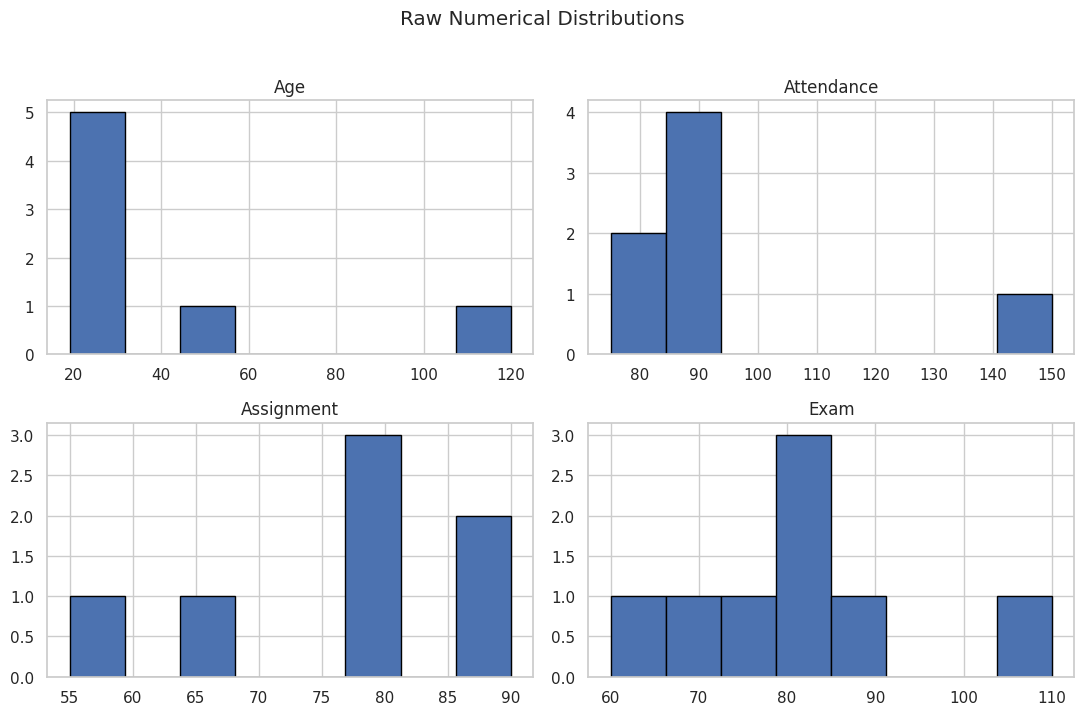

In [5]:
numerical_columns = ["Age", "Attendance", "Assignment", "Exam"]

raw_df[numerical_columns].hist(figsize=(11, 7), bins=8, edgecolor="black")
plt.suptitle("Raw Numerical Distributions", y=1.02)
plt.tight_layout()
plt.show()

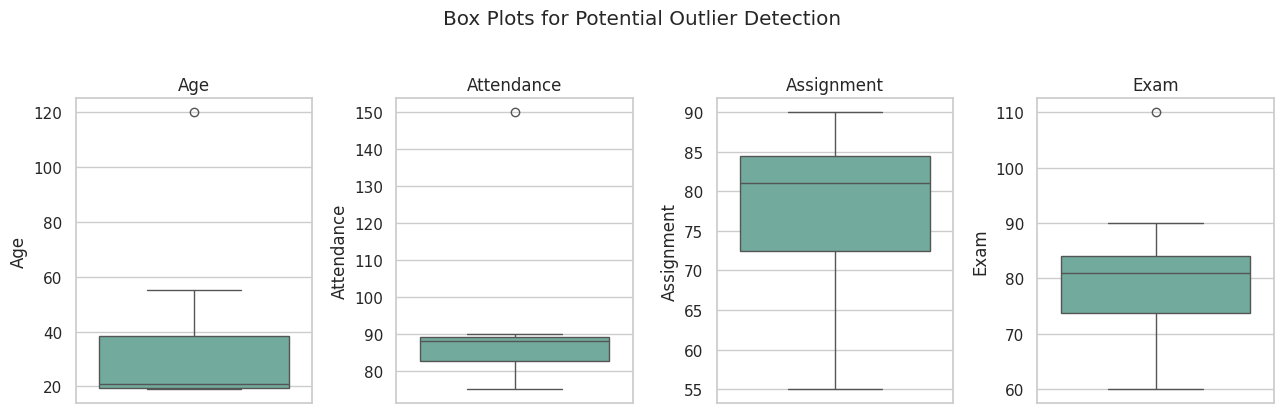

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for axis, column in zip(axes, numerical_columns):
    sns.boxplot(y=raw_df[column], ax=axis, color="#69b3a2")
    axis.set_title(column)
plt.suptitle("Box Plots for Potential Outlier Detection", y=1.03)
plt.tight_layout()
plt.show()

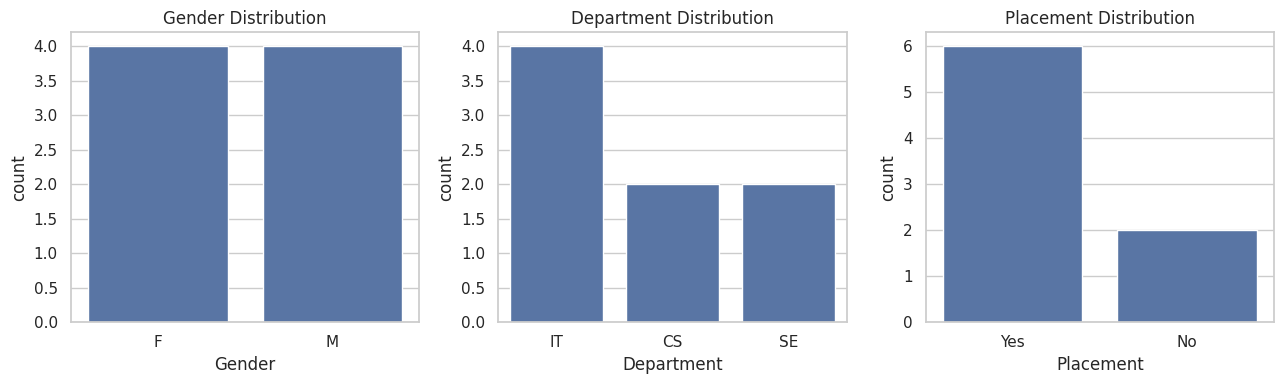

Placement counts:
 Placement
Yes    6
No     2
Name: count, dtype: int64

Placement percentages:
 Placement
Yes    75.0
No     25.0
Name: proportion, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for axis, column in zip(axes, ["Gender", "Department", "Placement"]):
    sns.countplot(data=raw_df, x=column, ax=axis)
    axis.set_title(f"{column} Distribution")
plt.tight_layout()
plt.show()

print("Placement counts:\n", raw_df["Placement"].value_counts())
print("\nPlacement percentages:\n", raw_df["Placement"].value_counts(normalize=True).mul(100).round(1))

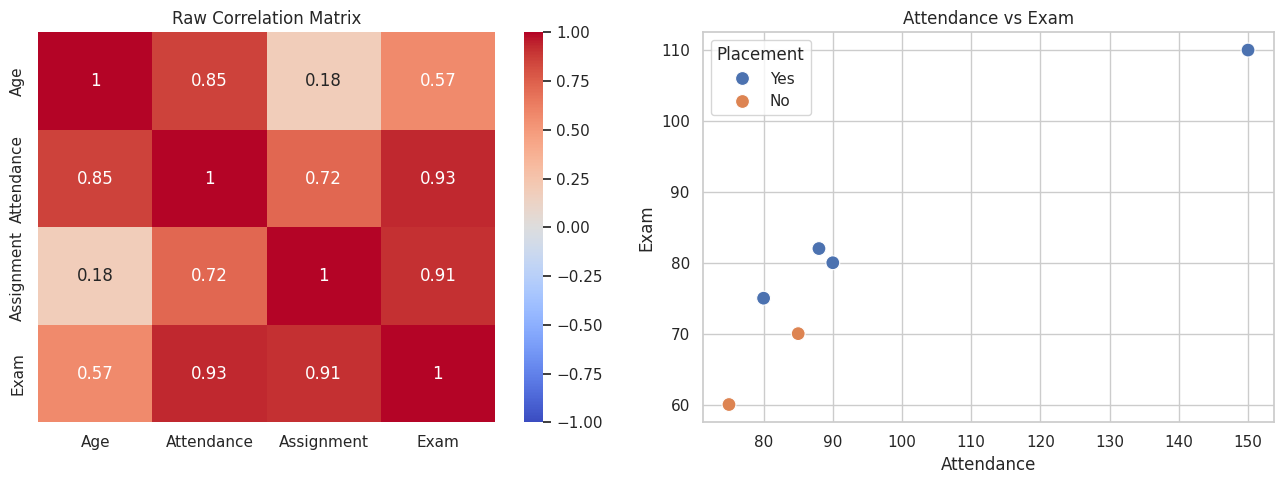

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    raw_df[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[0],
)
axes[0].set_title("Raw Correlation Matrix")

sns.scatterplot(
    data=raw_df,
    x="Attendance",
    y="Exam",
    hue="Placement",
    s=100,
    ax=axes[1],
)
axes[1].set_title("Attendance vs Exam")

plt.tight_layout()
plt.show()

print("Warning: eight rows and invalid values make these relationships unreliable.")

## 5. Correct IQR outlier detection

The original pasted code omitted comparison operators. This reusable function correctly returns values outside the IQR limits.

> A statistical outlier is not automatically an error. In cybersecurity, an outlier might be the attack we want to detect.

In [9]:
def find_iqr_outliers(dataframe, column):
    values = dataframe[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    mask = (dataframe[column] < lower_limit) | (dataframe[column] > upper_limit)
    return dataframe.loc[mask], lower_limit, upper_limit

for column in ["Age", "Attendance"]:
    outliers, lower, upper = find_iqr_outliers(raw_df, column)
    print(f"\n{column}: acceptable IQR range = {lower:.2f} to {upper:.2f}")
    display(outliers[["Student_ID", column]])


Age: acceptable IQR range = -9.00 to 67.00


,Student_ID,Age
6,107,120.0



Attendance: acceptable IQR range = 72.75 to 98.75


,Student_ID,Attendance
6,107,150.0


## 6. Deterministic cleaning before splitting

These rules use domain knowledge rather than statistics learned from the complete dataset:

1. Remove exact duplicates.
2. Standardise city capitalisation.
3. Convert values outside known valid ranges to missing.

We do **not** calculate replacement means/medians yet. Those values must be learned only from the training set.

In [10]:
clean_df = raw_df.copy()

# 1. Remove exact duplicate rows
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# 2. Standardise categorical text
clean_df["City"] = clean_df["City"].str.strip().str.title()

# 3. Apply transparent domain validation rules
valid_ranges = {
    "Age": (15, 100),
    "Attendance": (0, 100),
    "Assignment": (0, 100),
    "Exam": (0, 100),
}

invalid_report = []
for column, (minimum, maximum) in valid_ranges.items():
    invalid_mask = clean_df[column].notna() & ~clean_df[column].between(minimum, maximum)
    for index in clean_df.index[invalid_mask]:
        invalid_report.append({
            "row_index": index,
            "Student_ID": clean_df.loc[index, "Student_ID"],
            "column": column,
            "invalid_value": clean_df.loc[index, column],
            "action": "Converted to missing for later training-only imputation",
        })
    clean_df.loc[invalid_mask, column] = np.nan

print("Invalid values detected:")
display(pd.DataFrame(invalid_report))
print("Cleaned-but-not-imputed data:")
display(clean_df)

Invalid values detected:


,row_index,Student_ID,column,invalid_value,action
0,6,107,Age,120.0,Converted to missing for later training-only i...
1,6,107,Attendance,150.0,Converted to missing for later training-only i...
2,6,107,Exam,110.0,Converted to missing for later training-only i...


Cleaned-but-not-imputed data:


,Student_ID,Age,Gender,Department,Attendance,Assignment,Exam,City,Placement
0,101,20.0,F,IT,90.0,78.0,80.0,Colombo,Yes
1,102,21.0,M,CS,85.0,67.0,70.0,Kandy,No
2,103,NaN,M,IT,80.0,NaN,75.0,Colombo,Yes
3,104,22.0,F,SE,NaN,88.0,90.0,Galle,Yes
4,105,55.0,F,CS,75.0,55.0,60.0,Kandy,No
5,106,19.0,M,IT,88.0,81.0,82.0,Colombo,Yes
6,107,NaN,F,SE,NaN,90.0,NaN,Matara,Yes


In [11]:
# Validation checks: fail early if basic cleaning did not work
assert clean_df.duplicated().sum() == 0
assert clean_df["City"].str.lower().nunique() == clean_df["City"].nunique()
for column, (minimum, maximum) in valid_ranges.items():
    non_missing = clean_df[column].dropna()
    assert non_missing.between(minimum, maximum).all()

print("All deterministic cleaning checks passed.")

All deterministic cleaning checks passed.


## 7. Optional feature engineering: age groups

Fixed, domain-defined bins do not learn information from the test set. Keep the original `Age` as well so you can decide later whether grouping helps.

In [12]:
clean_df["Age_Group"] = pd.cut(
    clean_df["Age"],
    bins=[0, 20, 30, 40, 60, 100],
    labels=["20_or_under", "21_to_30", "31_to_40", "41_to_60", "61_to_100"],
)
clean_df[["Student_ID", "Age", "Age_Group"]]

,Student_ID,Age,Age_Group
0,101,20.0,20_or_under
1,102,21.0,21_to_30
2,103,NaN,NaN
3,104,22.0,21_to_30
4,105,55.0,41_to_60
5,106,19.0,20_or_under
6,107,NaN,NaN


## 8. Split before learned preprocessing

- `X` contains the input features.
- `y` contains the target (`Placement`).
- `Student_ID` is removed because it is an identifier, not a meaningful predictor.
- Stratification tries to preserve the Yes/No proportions in both subsets.

The dataset is extremely small, so this split is for demonstrating the workflow only.

In [13]:
X = clean_df.drop(columns=["Placement", "Student_ID", "Age_Group"])
y = clean_df["Placement"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTraining target counts:\n", y_train.value_counts())
print("\nTest target counts:\n", y_test.value_counts())

Training shape: (4, 7)
Test shape: (3, 7)

Training target counts:
 Placement
Yes    3
No     1
Name: count, dtype: int64

Test target counts:
 Placement
Yes    2
No     1
Name: count, dtype: int64


## 9. Leakage-safe preprocessing pipeline

For numerical features:

- Replace missing values using the **training-set median**.
- Standardise values using training-set mean and standard deviation.

For categorical features:

- Replace missing values using the training-set most-frequent category.
- Apply one-hot encoding.
- Ignore previously unseen test categories safely.

The pipeline ensures the imputer, encoder and scaler are fitted only during model training.

In [14]:
numeric_features = ["Age", "Attendance", "Assignment", "Exam"]
categorical_features = ["Gender", "Department", "City"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

model_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Attendance',
                                                   'Assignment', 'Exam']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Department',
                                                   'City'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [15]:
# Fit all learned preprocessing and the classifier using training data only
model_pipeline.fit(X_train, y_train)

feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()
transformed_train = model_pipeline.named_steps["preprocessor"].transform(X_train)

transformed_train_df = pd.DataFrame(
    transformed_train,
    columns=feature_names,
    index=X_train.index,
)

print("Transformed training data:")
display(transformed_train_df.round(3))

Transformed training data:


,numeric__Age,numeric__Attendance,numeric__Assignment,numeric__Exam,categorical__Gender_F,categorical__Gender_M,categorical__Department_CS,categorical__Department_IT,categorical__Department_SE,categorical__City_Colombo,categorical__City_Galle,categorical__City_Kandy,categorical__City_Matara
2,0.000,1.414,0.531,0.000,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
6,0.000,0.000,0.668,0.000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.414,-1.414,-1.729,-1.414,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.414,0.000,0.531,1.414,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## 10. Demonstration prediction and evaluation

Because the dataset has only seven unique records after cleaning, do **not** interpret these results as trustworthy model performance. This section only demonstrates the API.

,Age,Gender,Department,Attendance,Assignment,Exam,City,Actual_Placement,Predicted_Placement
1,21.0,M,CS,85.0,67.0,70.0,Kandy,No,Yes
0,20.0,F,IT,90.0,78.0,80.0,Colombo,Yes,Yes
5,19.0,M,IT,88.0,81.0,82.0,Colombo,Yes,Yes


              precision    recall  f1-score   support

          No       0.00      0.00      0.00         1
         Yes       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



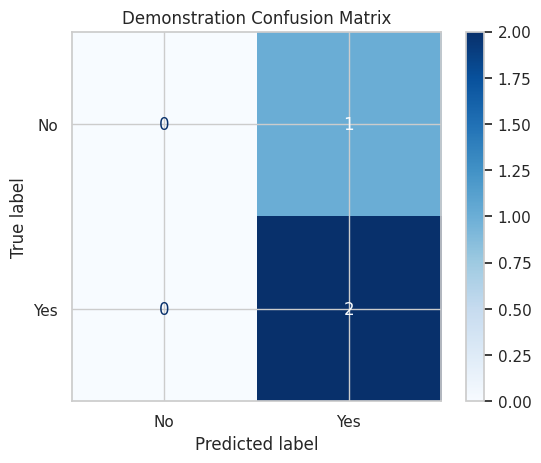

CAUTION: These metrics are unstable and not suitable for coursework conclusions.


In [16]:
predictions = model_pipeline.predict(X_test)

results = X_test.copy()
results["Actual_Placement"] = y_test
results["Predicted_Placement"] = predictions
display(results)

print(classification_report(y_test, predictions, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap="Blues")
plt.title("Demonstration Confusion Matrix")
plt.show()

print("CAUTION: These metrics are unstable and not suitable for coursework conclusions.")

## 11. Normalisation versus standardisation

- **Min-Max normalisation** usually maps training values to 0–1.
- **Standardisation** centres training values around zero using standard deviations.

Both scalers must be fitted only on training data. Test values can fall outside 0–1 with Min-Max scaling when they exceed the training range; this is expected and is not leakage.

In [17]:
# First impute numerical values using training data only
demo_imputer = SimpleImputer(strategy="median")
train_numeric = demo_imputer.fit_transform(X_train[numeric_features])

minmax = MinMaxScaler()
standard = StandardScaler()

minmax_values = minmax.fit_transform(train_numeric)
standard_values = standard.fit_transform(train_numeric)

print("Min-Max normalised training values:")
display(pd.DataFrame(minmax_values, columns=numeric_features).round(3))

print("Standardised training values:")
display(pd.DataFrame(standard_values, columns=numeric_features).round(3))

Min-Max normalised training values:


,Age,Attendance,Assignment,Exam
0,0.5,1.0,0.943,0.5
1,0.5,0.5,1.000,0.5
2,1.0,0.0,0.000,0.0
3,0.0,0.5,0.943,1.0


Standardised training values:


,Age,Attendance,Assignment,Exam
0,0.000,1.414,0.531,0.000
1,0.000,0.000,0.668,0.000
2,1.414,-1.414,-1.729,-1.414
3,-1.414,0.000,0.531,1.414


## 12. Student exercises

### Exercise 1 – Attendance outliers

Use `find_iqr_outliers()` to identify potential attendance outliers. Explain whether each value is statistically unusual, logically invalid, or both.

### Exercise 2 – One-hot encoding

Inspect `feature_names`. Explain why one-hot encoding is more suitable than assigning arbitrary numbers to `City` and `Department`.

### Exercise 3 – Invalid values

Change one assignment mark to `-5`. Re-run the cleaning section and confirm that the range-validation rule detects it.

### Exercise 4 – Age groups

Count the values in `Age_Group`, including missing values. Explain one advantage and one disadvantage of discretising age.

### Exercise 5 – Cybersecurity transfer

Imagine the rows are network flows and `Placement` is replaced by `Attack`. Identify:

- One possible invalid value
- One field that could leak the target
- One reason not to delete every outlier
- One reason accuracy alone could be misleading

In [18]:
# Exercise workspace

# 1. Detect Attendance outliers
attendance_outliers, attendance_lower, attendance_upper = find_iqr_outliers(raw_df, "Attendance")
display(attendance_outliers)

# 2. Inspect one-hot feature names
print(feature_names)

# 3. Count age groups, including missing
print(clean_df["Age_Group"].value_counts(dropna=False))

,Student_ID,Age,Gender,Department,Attendance,Assignment,Exam,City,Placement
6,107,120.0,F,SE,150.0,90.0,110,Matara,Yes


['numeric__Age' 'numeric__Attendance' 'numeric__Assignment'
 'numeric__Exam' 'categorical__Gender_F' 'categorical__Gender_M'
 'categorical__Department_CS' 'categorical__Department_IT'
 'categorical__Department_SE' 'categorical__City_Colombo'
 'categorical__City_Galle' 'categorical__City_Kandy'
 'categorical__City_Matara']
Age_Group
20_or_under    2
21_to_30       2
NaN            2
41_to_60       1
31_to_40       0
61_to_100      0
Name: count, dtype: int64


## 13. Key conclusions

1. **Profile before cleaning** so original problems remain visible.
2. **EDA informs decisions** but does not prove causation.
3. **Invalid values and statistical outliers are different concepts.**
4. **Do not delete cyber outliers automatically** because they may represent attacks.
5. **Split before learned preprocessing** to prevent data leakage.
6. **Fit imputers, encoders and scalers on training data only.**
7. **Use pipelines** to keep training and future prediction transformations consistent.
8. **Do not draw performance conclusions from a tiny teaching dataset.**